# Histopathology-referenced UMAP for MRI embedding comparison

This notebook uses **histopathology as the reference manifold**.

It now does four things:

1. loads the histopathology embeddings for the chosen split,
2. loads histopathology **ISUP grades (0–5)** from the corresponding `{SET}.csv`,
3. creates a **merged 3-class histo label view** (`ISUP01`, `ISUP23`, `ISUP45`) to match MRI,
4. shows a **small grid of candidate histo UMAPs** so you can pick a clearer reference layout,
5. fits **one chosen UMAP on the histopathology space only**, and
6. projects both MRI embedding sets into that same learned 2D space with `reducer.transform(...)`.

## Why this is better than separate UMAPs
Separate UMAP fits are not directly comparable. They can rotate, stretch, or fragment the structure differently across runs.  
Here, the MRI embeddings are always shown in the **same 2D coordinate system defined by histopathology**.

## Labeling convention
- **Histo, 6-class view:** colored by `isup_grade` = `0,1,2,3,4,5`
- **Histo, merged 3-class view:** `0–1 -> ISUP01`, `2–3 -> ISUP23`, `4–5 -> ISUP45`
- **MRI plots:** colored by their native 3-class labels

## Important caveat
This projection is most meaningful if the MRI and histopathology embeddings are in the same 512D feature space, or at least similar enough that the feature axes are comparable. That assumption is much more defensible for the aligned MRI embeddings than for the baseline embeddings.


In [ ]:
# --- Paths / settings (EDIT ME) ---

# MRI runs
RUN_DIR_A = "/home/ewillis/projects/aip-medilab/ewillis/pca_contrastive/mri_model_medsam_finetune_2D/LATEST/SPIE-RESULTS: results_isup3/baseline/val0-test4"
RUN_DIR_B = "/home/ewillis/projects/aip-medilab/ewillis/pca_contrastive/mri_model_medsam_finetune_2D/LATEST/SPIE-RESULTS: results_isup3/head_only/val0-test4"

NAME_A = "Baseline"
NAME_B = "Aligned"

SET = "test"   # one of: train / val / test

PT_A = f"{RUN_DIR_A}/{SET}_embeddings/{SET}.pt"
PT_B = f"{RUN_DIR_B}/{SET}_embeddings/{SET}.pt"

# Optional MRI metadata CSVs
META_A = None
META_B = None

# Histopathology embeddings
HISTO_ROOT = "/project/aip-medilab/shared/picai/histopathology_encodings/UNI2/projected_512D/embeddings_512"
HISTO_DIR = f"{HISTO_ROOT}/{SET}"

# Histopathology labels CSV
HISTO_LABELS_ROOT = "/project/aip-medilab/shared/picai/histopathology_encodings/UNI2_splits"
HISTO_LABELS_CSV = f"{HISTO_LABELS_ROOT}/{SET}.csv"
HISTO_ID_COL = "FILENAME"
HISTO_LABEL_COL = "isup_grade"

# Histopathology filename pattern
HISTO_SUFFIX = "_abmil512.npy"

# Preprocessing before UMAP
APPLY_L2_NORM = True
APPLY_STANDARD_SCALER = True
USE_PCA = True
PCA_N_COMPONENTS = 50

# Small grid of candidate UMAP settings for histo.
# You can add/remove entries here.
UMAP_PARAM_GRID = [
    {"n_neighbors": 10, "min_dist": 0.00, "metric": "cosine", "random_state": 42, "n_components": 2},
    {"n_neighbors": 15, "min_dist": 0.00, "metric": "cosine", "random_state": 42, "n_components": 2},
    {"n_neighbors": 30, "min_dist": 0.00, "metric": "cosine", "random_state": 42, "n_components": 2},
    {"n_neighbors": 15, "min_dist": 0.10, "metric": "cosine", "random_state": 42, "n_components": 2},
    {"n_neighbors": 30, "min_dist": 0.10, "metric": "cosine", "random_state": 42, "n_components": 2},
    {"n_neighbors": 50, "min_dist": 0.20, "metric": "cosine", "random_state": 42, "n_components": 2},
]

# Which candidate should be used as the final reference space?
SELECTED_UMAP_INDEX = 1

# Colors
HISTO6_COLORS = {
    0: "#4C78A8",
    1: "#F58518",
    2: "#54A24B",
    3: "#E45756",
    4: "#72B7B2",
    5: "#B279A2",
}
MERGED3_COLORS = {
    0: "#4C78A8",
    1: "#F58518",
    2: "#E45756",
}

# Point sizes / alpha
S_HISTO = 8
S_MRI = 8
ALPHA = 0.75
MRI_ALPHA = 0.55


In [ ]:
import os
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

try:
    import umap.umap_ as umap
except Exception:
    raise RuntimeError("Please install umap-learn: pip install umap-learn")

import torch


/project/aip-medilab/ewillis/pca_contrastive/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def _unpack_pt_payload(payload):
    emb = None
    y = None

    if isinstance(payload, dict):
        for k in ("embeddings", "embedding", "X", "features"):
            if k in payload:
                emb = payload[k]
                break
        for k in ("labels", "label", "y", "targets"):
            if k in payload:
                y = payload[k]
                break
    elif isinstance(payload, (tuple, list)) and len(payload) >= 2:
        emb, y = payload[0], payload[1]
    else:
        raise ValueError(
            f"Unsupported payload type: {type(payload)}. Expected dict or (embeddings, labels)."
        )

    if emb is None or y is None:
        raise ValueError("Could not find both embeddings and labels in the .pt file.")

    emb = emb.detach().cpu().numpy() if torch.is_tensor(emb) else np.asarray(emb)
    y = y.detach().cpu().numpy() if torch.is_tensor(y) else np.asarray(y)
    return emb, y


def load_encodings_pt(pt_path, meta_path=None):
    payload = torch.load(pt_path, map_location="cpu")
    emb, labels = _unpack_pt_payload(payload)

    if meta_path is not None:
        meta = pd.read_csv(meta_path)
        assert len(meta) == len(labels) == emb.shape[0], "Mismatch among emb / labels / meta."
    else:
        meta = pd.DataFrame(index=range(len(labels)))

    return emb, labels, meta


def _l2_normalize(X, eps=1e-12):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.clip(norms, eps, None)


def build_palette(label_array, label_names=None, colors=None):
    if label_array is None:
        return {}, {}

    vals = pd.Series(label_array).dropna().astype(int).unique().tolist()
    uniq = sorted(set(vals))

    if label_names is None:
        label_names = {int(k): str(int(k)) for k in uniq}
    else:
        label_names = {int(k): label_names.get(int(k), str(int(k))) for k in uniq}

    if isinstance(colors, dict) and len(colors) > 0:
        from itertools import cycle
        default_colors = cycle(plt.rcParams["axes.prop_cycle"].by_key().get("color", []))
        palette = {}
        for k in uniq:
            palette[int(k)] = colors.get(int(k), None)
            if palette[int(k)] is None:
                palette[int(k)] = next(default_colors)
    else:
        from itertools import cycle
        cyc = cycle(plt.rcParams["axes.prop_cycle"].by_key().get("color", []))
        palette = {int(k): next(cyc) for k in uniq}

    return palette, label_names


def merge_isup6_to_isup3(arr):
    if arr is None:
        return None
    arr = np.asarray(arr)
    out = np.full(arr.shape, np.nan, dtype=float)
    valid = ~pd.isna(arr)
    arrv = arr[valid].astype(int)
    outv = np.full(arrv.shape, np.nan, dtype=float)
    outv[(arrv >= 0) & (arrv <= 1)] = 0
    outv[(arrv >= 2) & (arrv <= 3)] = 1
    outv[(arrv >= 4) & (arrv <= 5)] = 2
    out[valid] = outv
    return out


def load_histo_embeddings(histo_dir, suffix="_abmil512.npy", labels_csv=None, id_col="FILENAME", label_col="isup_grade"):
    files = sorted(glob.glob(os.path.join(histo_dir, f"*{suffix}")))
    if len(files) == 0:
        raise FileNotFoundError(f"No histopathology embeddings found in: {histo_dir}")

    ids = [os.path.basename(f).replace(suffix, "") for f in files]
    X = np.stack([np.load(f) for f in files], axis=0)
    meta = pd.DataFrame({"id": ids, "path": files})
    y = None

    if labels_csv is not None:
        labels_df = pd.read_csv(labels_csv)
        if id_col not in labels_df.columns or label_col not in labels_df.columns:
            raise ValueError(
                f"labels_csv must contain columns '{id_col}' and '{label_col}'. Found: {list(labels_df.columns)}"
            )

        keep_cols = [c for c in [id_col, label_col, "PATIENT", "data_provider", "image_fn", "strat_label"] if c in labels_df.columns]
        labels_df = labels_df[keep_cols].copy()
        labels_df = labels_df.rename(columns={id_col: "id", label_col: "label"})

        meta = meta.merge(labels_df, on="id", how="left")
        matched = meta["label"].notna().sum()
        print(f"Matched histo labels for {matched}/{len(meta)} embeddings from {labels_csv}.")
        if matched > 0:
            y = meta["label"].to_numpy()

    return X, y, meta


class HistoReferenceProjector:
    """Fit preprocessing + UMAP on histopathology, then project MRI spaces into it."""

    def __init__(self, apply_l2_norm=True, apply_standard_scaler=True, use_pca=True, pca_n_components=50, umap_params=None):
        self.apply_l2_norm = apply_l2_norm
        self.apply_standard_scaler = apply_standard_scaler
        self.use_pca = use_pca
        self.pca_n_components = pca_n_components
        self.umap_params = umap_params or {}
        self.scaler = None
        self.pca = None
        self.reducer = None

    def _pre_transform_only(self, X):
        Z = np.asarray(X).copy()
        if self.apply_l2_norm:
            Z = _l2_normalize(Z)
        if self.scaler is not None:
            Z = self.scaler.transform(Z)
        if self.pca is not None:
            Z = self.pca.transform(Z)
        return Z

    def fit(self, X_ref):
        Z = np.asarray(X_ref).copy()
        if self.apply_l2_norm:
            Z = _l2_normalize(Z)

        if self.apply_standard_scaler:
            self.scaler = StandardScaler()
            Z = self.scaler.fit_transform(Z)

        if self.use_pca:
            n_comp = min(self.pca_n_components, Z.shape[0], Z.shape[1])
            self.pca = PCA(n_components=n_comp, random_state=42)
            Z = self.pca.fit_transform(Z)

        self.reducer = umap.UMAP(**self.umap_params)
        self.reducer.fit(Z)
        return self

    def transform_features(self, X):
        return self._pre_transform_only(X)

    def transform_2d(self, X):
        Z = self._pre_transform_only(X)
        return self.reducer.transform(Z)


def scatter_by_label(ax, X2, y, title, palette, label_names, s=8, alpha=0.75, fallback_color="#808080", legend=True):
    if y is None:
        ax.scatter(X2[:, 0], X2[:, 1], s=s, alpha=alpha, c=fallback_color)
        ax.set_title(title + " (unlabeled)")
        ax.set_xlabel("UMAP-1")
        ax.set_ylabel("UMAP-2")
        return

    y = np.asarray(y)
    valid = ~pd.isna(y)
    y_float = np.full(y.shape, np.nan, dtype=float)
    y_float[valid] = y[valid].astype(float)

    uniq = sorted(pd.unique(pd.Series(y[valid]).astype(int)))
    for k in uniq:
        m = valid & (y_float == float(k))
        ax.scatter(
            X2[m, 0],
            X2[m, 1],
            s=s,
            alpha=alpha,
            label=label_names.get(int(k), str(k)),
            c=palette.get(int(k), fallback_color),
        )

    if (~valid).any():
        ax.scatter(X2[~valid, 0], X2[~valid, 1], s=s, alpha=0.25, c=fallback_color, label="unlabeled")

    ax.set_title(title)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    if legend:
        ax.legend(loc="best")


def safe_silhouette(X, y, metric="euclidean"):
    if y is None:
        return np.nan
    y = np.asarray(y)
    valid = ~pd.isna(y)
    Xv = X[valid]
    yv = y[valid]
    if len(np.unique(yv)) < 2:
        return np.nan
    return silhouette_score(Xv, yv, metric=metric)


In [ ]:
# --- Load data ---
embA, yA, metaA = load_encodings_pt(PT_A, META_A)
embB, yB, metaB = load_encodings_pt(PT_B, META_B)
embH, yH6, metaH = load_histo_embeddings(
    HISTO_DIR,
    suffix=HISTO_SUFFIX,
    labels_csv=HISTO_LABELS_CSV,
    id_col=HISTO_ID_COL,
    label_col=HISTO_LABEL_COL,
)

print(f"Histo : {embH.shape}")
print(f"{NAME_A}: {embA.shape}")
print(f"{NAME_B}: {embB.shape}")

if embA.shape[1] != embH.shape[1] or embB.shape[1] != embH.shape[1]:
    raise ValueError(
        f"Embedding dims do not match. histo={embH.shape[1]}, {NAME_A}={embA.shape[1]}, {NAME_B}={embB.shape[1]}"
    )

# Labels
yH3 = merge_isup6_to_isup3(yH6)

histo6_names = {0: "ISUP_0", 1: "ISUP_1", 2: "ISUP_2", 3: "ISUP_3", 4: "ISUP_4", 5: "ISUP_5"}
merged3_names = {0: "ISUP01", 1: "ISUP23", 2: "ISUP45"}
mri_names = {0: "ISUP01", 1: "ISUP23", 2: "ISUP45"}

histo6_palette, histo6_names = build_palette(yH6, label_names=histo6_names, colors=HISTO6_COLORS)
merged3_palette, merged3_names = build_palette(yH3, label_names=merged3_names, colors=MERGED3_COLORS)
mri_palette, mri_names = build_palette(np.concatenate([np.asarray(yA).ravel(), np.asarray(yB).ravel()]), label_names=mri_names, colors=MERGED3_COLORS)

print("Histo 6-class counts:")
print(pd.Series(yH6).dropna().astype(int).value_counts().sort_index())
print("\nHisto merged 3-class counts:")
print(pd.Series(yH3).dropna().astype(int).value_counts().sort_index())
print("\nMRI A counts:")
print(pd.Series(yA).dropna().astype(int).value_counts().sort_index())
print("\nMRI B counts:")
print(pd.Series(yB).dropna().astype(int).value_counts().sort_index())


Matched histo labels for 954/954 embeddings from /project/aip-medilab/shared/picai/histopathology_encodings/UNI2_splits/test.csv.
Histo : (954, 512)
Baseline: (6762, 512)
Aligned: (6762, 512)
Histo 6-class counts:
0    260
1    240
2    121
3    111
4    112
5    110
Name: count, dtype: int64

Histo merged 3-class counts:
0    500
1    232
2    222
Name: count, dtype: int64

MRI A counts:
0    6253
1     413
2      96
Name: count, dtype: int64

MRI B counts:
0    6253
1     413
2      96
Name: count, dtype: int64


In [ ]:
# --- Histo preprocessing once, then compare candidate UMAP settings ---
base_preprocessor = HistoReferenceProjector(
    apply_l2_norm=APPLY_L2_NORM,
    apply_standard_scaler=APPLY_STANDARD_SCALER,
    use_pca=USE_PCA,
    pca_n_components=PCA_N_COMPONENTS,
    umap_params={"n_neighbors": 15, "min_dist": 0.1, "metric": "cosine", "random_state": 42, "n_components": 2},
).fit(embH)

ZH = base_preprocessor.transform_features(embH)
print("Preprocessed histo feature shape:", ZH.shape)

grid_results = []
coords_grid = []

for idx, params in enumerate(UMAP_PARAM_GRID):
    reducer = umap.UMAP(**params)
    H2_candidate = reducer.fit_transform(ZH)
    sil3 = safe_silhouette(H2_candidate, yH3, metric="euclidean")
    sil6 = safe_silhouette(H2_candidate, yH6, metric="euclidean")
    coords_grid.append(H2_candidate)
    grid_results.append({
        "index": idx,
        "n_neighbors": params["n_neighbors"],
        "min_dist": params["min_dist"],
        "metric": params["metric"],
        "silhouette_histo3": sil3,
        "silhouette_histo6": sil6,
    })

grid_df = pd.DataFrame(grid_results).sort_values("index").reset_index(drop=True)
grid_df


/project/aip-medilab/ewillis/pca_contrastive/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Preprocessed histo feature shape: (954, 50)


/project/aip-medilab/ewillis/pca_contrastive/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/project/aip-medilab/ewillis/pca_contrastive/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/project/aip-medilab/ewillis/pca_contrastive/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/project/aip-medilab/ewillis/pca_contrastive/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/project/aip-medilab/ewillis/pca_contrastive/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed 

,index,n_neighbors,min_dist,metric,silhouette_histo3,silhouette_histo6
0,0,10,0.0,cosine,0.067212,-0.036409
1,1,15,0.0,cosine,0.042814,-0.032567
2,2,30,0.0,cosine,0.047497,-0.035791
3,3,15,0.1,cosine,0.049422,-0.033183
4,4,30,0.1,cosine,0.043679,-0.004079
5,5,50,0.2,cosine,0.098113,0.036680


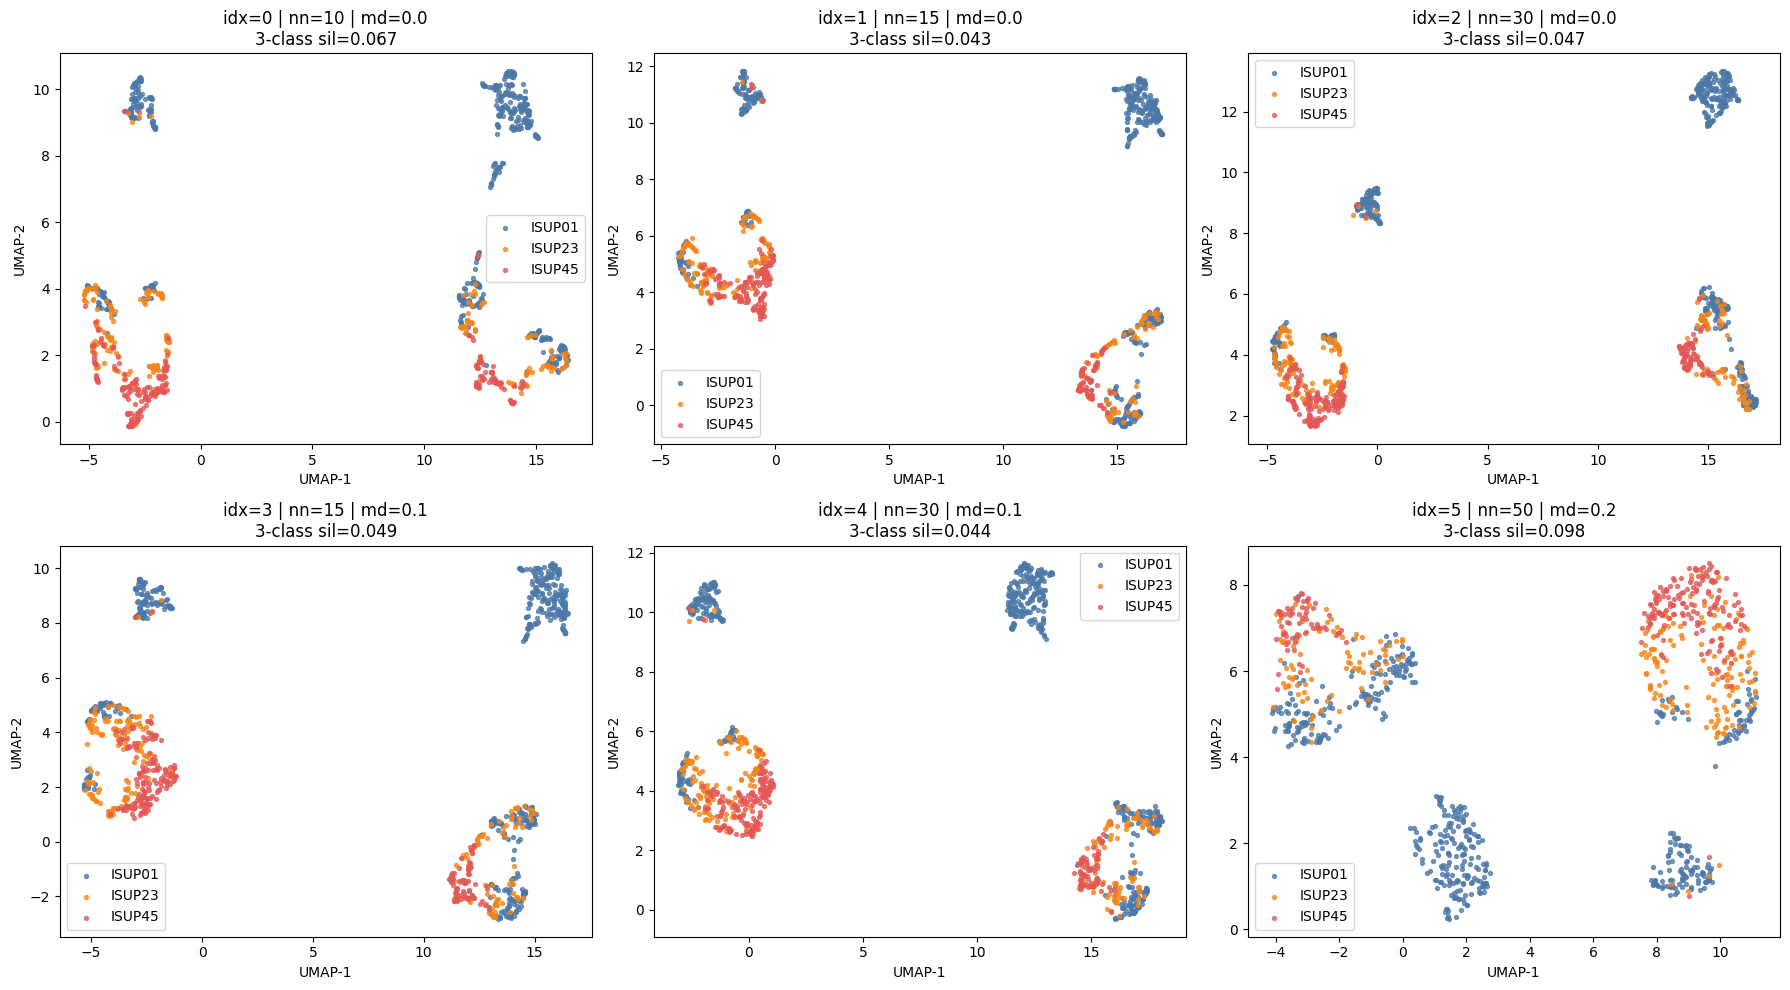

In [ ]:
# --- Candidate histo UMAPs, colored by merged 3-class labels ---
n = len(coords_grid)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)
axes = axes.ravel()

for idx, (ax, H2_candidate) in enumerate(zip(axes, coords_grid)):
    params = UMAP_PARAM_GRID[idx]
    sil3 = grid_df.loc[grid_df["index"] == idx, "silhouette_histo3"].iloc[0]
    title = f"idx={idx} | nn={params['n_neighbors']} | md={params['min_dist']}\n3-class sil={sil3:.3f}"
    scatter_by_label(ax, H2_candidate, yH3, title, merged3_palette, merged3_names, s=S_HISTO, alpha=ALPHA)

for j in range(len(coords_grid), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# --- Fit the chosen histo reference projector ---
SELECTED_UMAP_PARAMS = UMAP_PARAM_GRID[SELECTED_UMAP_INDEX]
print("Using UMAP params:", SELECTED_UMAP_PARAMS)

projector = HistoReferenceProjector(
    apply_l2_norm=APPLY_L2_NORM,
    apply_standard_scaler=APPLY_STANDARD_SCALER,
    use_pca=USE_PCA,
    pca_n_components=PCA_N_COMPONENTS,
    umap_params=SELECTED_UMAP_PARAMS,
).fit(embH)

ZH = projector.transform_features(embH)
ZA = projector.transform_features(embA)
ZB = projector.transform_features(embB)

H2 = projector.transform_2d(embH)
A2 = projector.transform_2d(embA)
B2 = projector.transform_2d(embB)

print("Projected all datasets into the chosen histopathology-defined UMAP space.")
print("Silhouette summary:")
print("  Histo 6-class:", safe_silhouette(H2, yH6))
print("  Histo 3-class:", safe_silhouette(H2, yH3))
print(f"  {NAME_A} 3-class:", safe_silhouette(A2, yA))
print(f"  {NAME_B} 3-class:", safe_silhouette(B2, yB))


Using UMAP params: {'n_neighbors': 15, 'min_dist': 0.0, 'metric': 'cosine', 'random_state': 42, 'n_components': 2}


/project/aip-medilab/ewillis/pca_contrastive/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Projected all datasets into the chosen histopathology-defined UMAP space.
Silhouette summary:
  Histo 6-class: -0.010723465122282505
  Histo 3-class: 0.0721215009689331
  Baseline 3-class: -0.05838262662291527
  Aligned 3-class: 0.3649623394012451


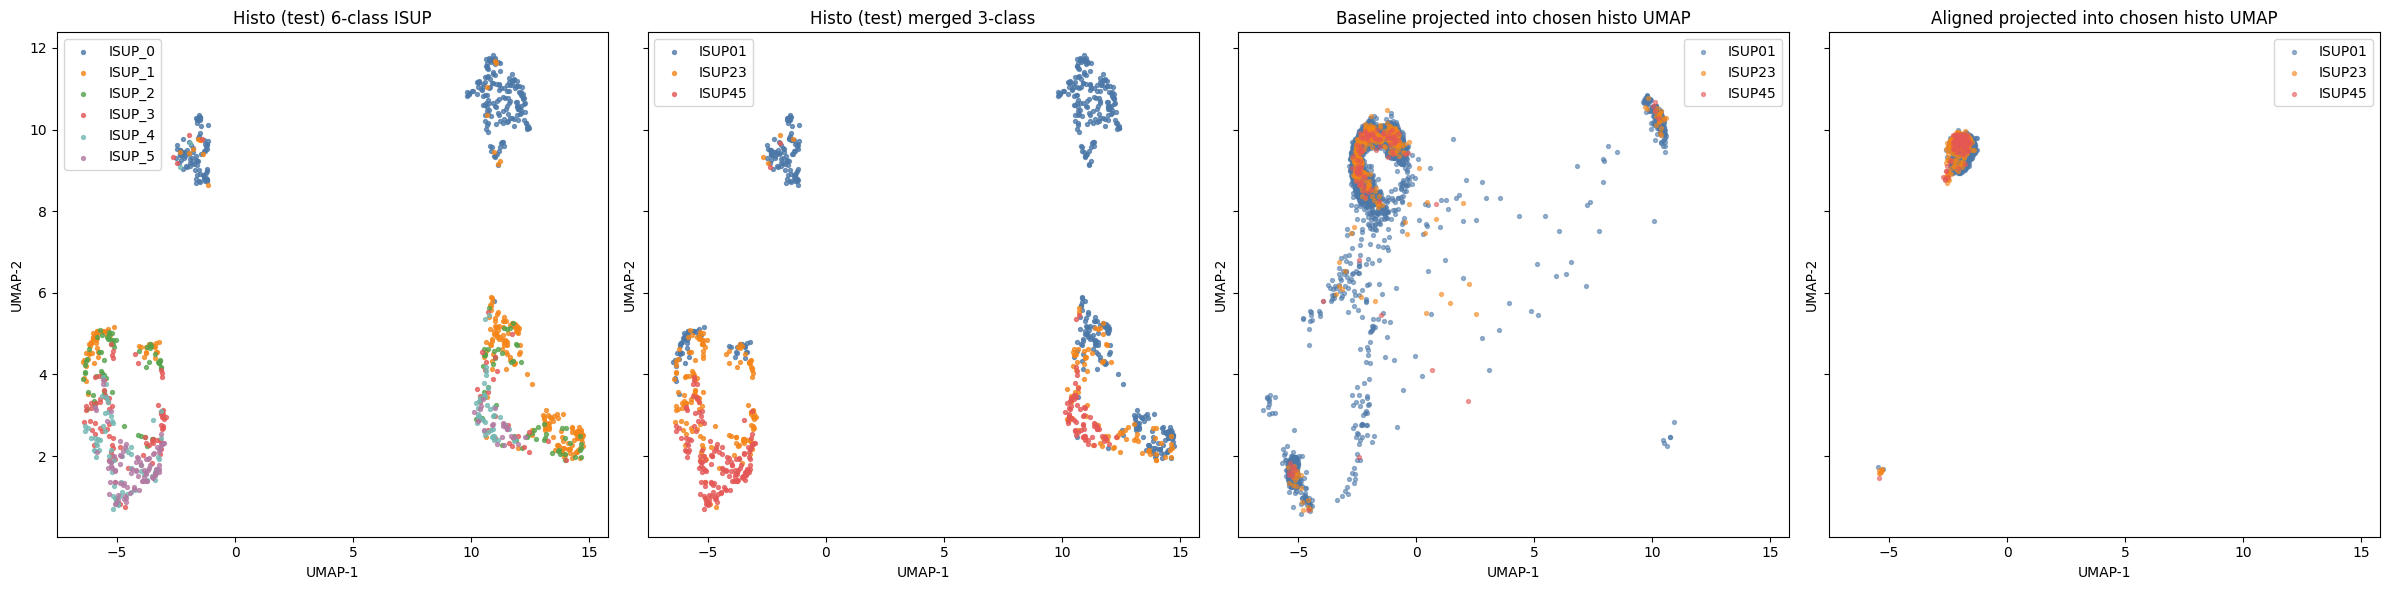

In [ ]:
# --- Main comparison plots ---
xmin = min(H2[:, 0].min(), A2[:, 0].min(), B2[:, 0].min())
xmax = max(H2[:, 0].max(), A2[:, 0].max(), B2[:, 0].max())
ymin = min(H2[:, 1].min(), A2[:, 1].min(), B2[:, 1].min())
ymax = max(H2[:, 1].max(), A2[:, 1].max(), B2[:, 1].max())
pad_x = 0.05 * (xmax - xmin + 1e-9)
pad_y = 0.05 * (ymax - ymin + 1e-9)

fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharex=True, sharey=True)

scatter_by_label(axes[0], H2, yH6, f"Histo ({SET}) 6-class ISUP", histo6_palette, histo6_names, s=S_HISTO, alpha=ALPHA)
scatter_by_label(axes[1], H2, yH3, f"Histo ({SET}) merged 3-class", merged3_palette, merged3_names, s=S_HISTO, alpha=ALPHA)
scatter_by_label(axes[2], A2, yA, f"{NAME_A} projected into chosen histo UMAP", mri_palette, mri_names, s=S_MRI, alpha=MRI_ALPHA)
scatter_by_label(axes[3], B2, yB, f"{NAME_B} projected into chosen histo UMAP", mri_palette, mri_names, s=S_MRI, alpha=MRI_ALPHA)

for ax in axes:
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

plt.tight_layout()
plt.show()


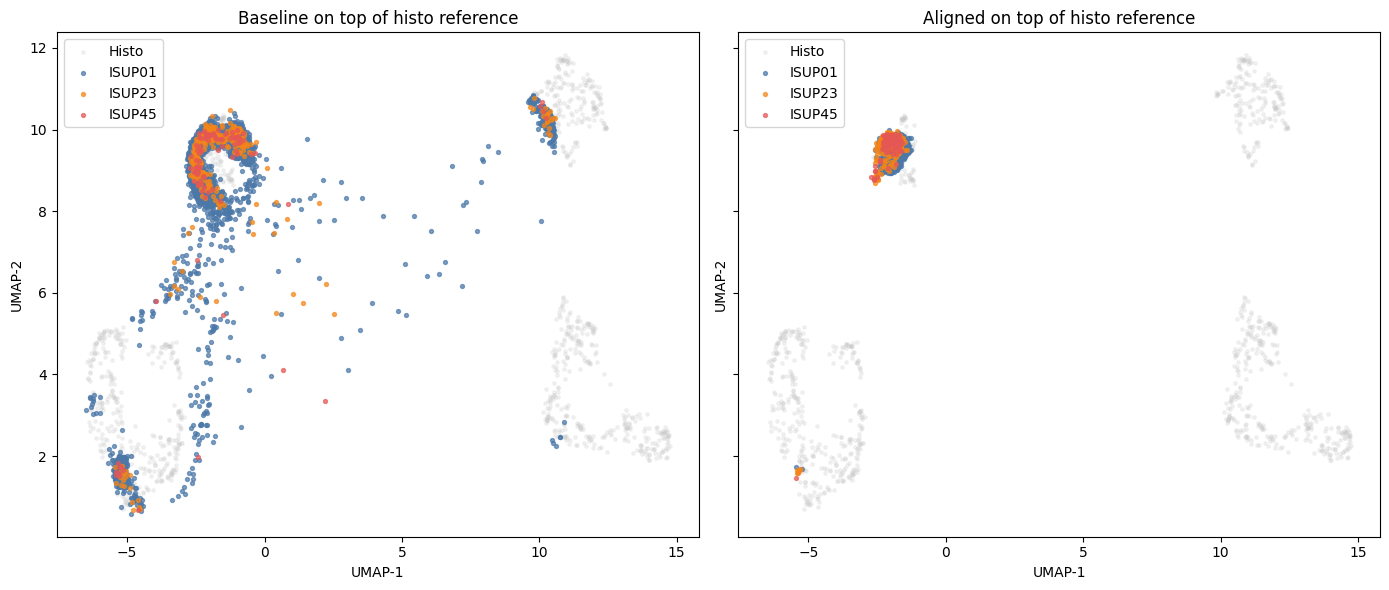

In [ ]:
# --- Optional overlay views: histo background + MRI on top ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Baseline overlay
axes[0].scatter(H2[:, 0], H2[:, 1], s=6, c="#C7C7C7", alpha=0.20, label="Histo")
for k in sorted(pd.unique(pd.Series(yA).dropna().astype(int))):
    m = np.asarray(yA).astype(int) == int(k)
    axes[0].scatter(A2[m, 0], A2[m, 1], s=S_MRI, alpha=0.70, c=mri_palette[k], label=mri_names[k])
axes[0].set_title(f"{NAME_A} on top of histo reference")
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")
axes[0].legend(loc="best")

# Aligned overlay
axes[1].scatter(H2[:, 0], H2[:, 1], s=6, c="#C7C7C7", alpha=0.20, label="Histo")
for k in sorted(pd.unique(pd.Series(yB).dropna().astype(int))):
    m = np.asarray(yB).astype(int) == int(k)
    axes[1].scatter(B2[m, 0], B2[m, 1], s=S_MRI, alpha=0.70, c=mri_palette[k], label=mri_names[k])
axes[1].set_title(f"{NAME_B} on top of histo reference")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")
axes[1].legend(loc="best")

for ax in axes:
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

plt.tight_layout()
plt.show()


## MRI-only UMAPs (no histopathology registration)
These plots fit UMAP **separately on each MRI embedding set**, so they show the intrinsic MRI geometry rather than placement inside the histopathology reference manifold.

/project/aip-medilab/ewillis/pca_contrastive/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/project/aip-medilab/ewillis/pca_contrastive/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


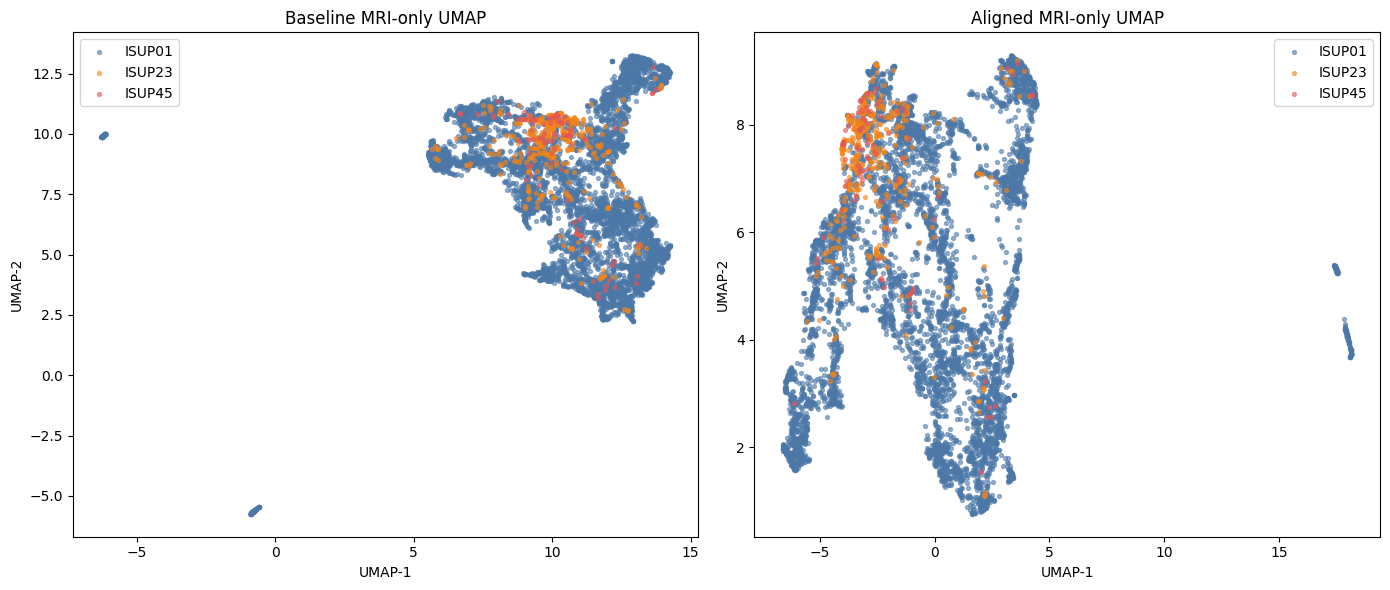

Silhouette in MRI-only UMAP space
Baseline: -0.1662
Aligned: -0.0900


In [ ]:

# --- MRI-only UMAPs (fit separately; not registered to histo) ---

def fit_umap_direct(X, apply_l2_norm=True, apply_standard_scaler=True, use_pca=True, pca_n_components=50, umap_params=None):
    Z = np.asarray(X).copy()

    if apply_l2_norm:
        Z = _l2_normalize(Z)

    if apply_standard_scaler:
        scaler = StandardScaler()
        Z = scaler.fit_transform(Z)

    if use_pca:
        n_comp = min(pca_n_components, Z.shape[0], Z.shape[1])
        pca = PCA(n_components=n_comp, random_state=42)
        Z = pca.fit_transform(Z)

    reducer = umap.UMAP(**(umap_params or {}))
    X2 = reducer.fit_transform(Z)
    return X2

# Use the same selected hyperparameters for a fair visual comparison,
# but fit the reducer independently on each MRI space.
mri_umap_params = dict(SELECTED_UMAP_PARAMS)

A2_direct = fit_umap_direct(
    embA,
    apply_l2_norm=APPLY_L2_NORM,
    apply_standard_scaler=APPLY_STANDARD_SCALER,
    use_pca=USE_PCA,
    pca_n_components=PCA_N_COMPONENTS,
    umap_params=mri_umap_params,
)

B2_direct = fit_umap_direct(
    embB,
    apply_l2_norm=APPLY_L2_NORM,
    apply_standard_scaler=APPLY_STANDARD_SCALER,
    use_pca=USE_PCA,
    pca_n_components=PCA_N_COMPONENTS,
    umap_params=mri_umap_params,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)

scatter_by_label(
    axes[0], A2_direct, yA,
    f"{NAME_A} MRI-only UMAP",
    mri_palette, mri_names,
    s=S_MRI, alpha=MRI_ALPHA
)

scatter_by_label(
    axes[1], B2_direct, yB,
    f"{NAME_B} MRI-only UMAP",
    mri_palette, mri_names,
    s=S_MRI, alpha=MRI_ALPHA
)

plt.tight_layout()
plt.show()

print("Silhouette in MRI-only UMAP space")
print(f"{NAME_A}: {safe_silhouette(A2_direct, yA):.4f}")
print(f"{NAME_B}: {safe_silhouette(B2_direct, yB):.4f}")


In [ ]:
# --- Optional: save projected coordinates and the candidate-grid summary ---
save_dir = "./umap_outputs"
os.makedirs(save_dir, exist_ok=True)

pd.DataFrame({
    "umap1": H2[:, 0],
    "umap2": H2[:, 1],
    "label_isup6": yH6 if yH6 is not None else np.nan,
    "label_isup3": yH3 if yH3 is not None else np.nan,
    "id": metaH["id"],
}).to_csv(os.path.join(save_dir, f"histo_{SET}_projected.csv"), index=False)

pd.DataFrame({
    "umap1": A2[:, 0],
    "umap2": A2[:, 1],
    "label": yA,
}).to_csv(os.path.join(save_dir, f"mri_{SET}_{NAME_A.lower().replace(' ', '_')}_in_histo_umap.csv"), index=False)

pd.DataFrame({
    "umap1": B2[:, 0],
    "umap2": B2[:, 1],
    "label": yB,
}).to_csv(os.path.join(save_dir, f"mri_{SET}_{NAME_B.lower().replace(' ', '_')}_in_histo_umap.csv"), index=False)

grid_df.to_csv(os.path.join(save_dir, f"histo_umap_grid_summary_{SET}.csv"), index=False)

print(f"Saved outputs to: {os.path.abspath(save_dir)}")


Saved outputs to: /project/6106383/ewillis/pca_contrastive/mri_model_medsam_finetune_2D/LATEST/umap_outputs
